# MELD Dataset Exploration

Dieses Notebook dient dem ersten Kennenlernen des MELD-Datensatzes.
Wir untersuchen Klassenverteilung, Transkriptlängen, Split-Grössen und laden ein Audio-Sample.

**Ziel:** Verstehen der Datenstruktur, bevor wir mit dem Modelltraining beginnen.

## 1. Imports & Konfiguration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ftfy
from pathlib import Path
from collections import Counter

# Für Audio-Analyse (optional, nur wenn Audio vorhanden)
try:
    import librosa
    import librosa.display
    LIBROSA_AVAILABLE = True
except ImportError:
    LIBROSA_AVAILABLE = False
    print("librosa nicht installiert – Audio-Zellen werden übersprungen.")

# Einheitliches Plot-Theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# -------------------------------------------------------
# Pfade anpassen, falls MELD woanders liegt
# -------------------------------------------------------
DATA_ROOT = Path("../data/raw")          # Ordner mit den MELD CSV-Dateien
AUDIO_ROOT = Path("../data/MELD.Raw/audio")   # Ordner mit den .wav-Dateien (falls vorhanden)

EMOTION_ORDER = [
    "neutral", "joy", "sadness", "anger",
    "surprise", "disgust", "fear"
]

EMOTION_COLORS = {
    "neutral":  "#888780",
    "joy":      "#639922",
    "sadness":  "#378ADD",
    "anger":    "#E24B4A",
    "surprise": "#EF9F27",
    "disgust":  "#D4537E",
    "fear":     "#7F77DD",
}

print("Setup abgeschlossen.")

librosa nicht installiert – Audio-Zellen werden übersprungen.
Setup abgeschlossen.


## 2. CSV-Dateien laden

MELD liefert drei CSV-Dateien:
- `train_sent_emo.csv` – Trainingsdaten
- `dev_sent_emo.csv`   – Validierungsdaten
- `test_sent_emo.csv`  – Testdaten

Wichtige Spalten:
| Spalte | Bedeutung |
|--------|----------|
| `Sr No.` | Laufende Nummer |
| `Utterance` | Transkripttext |
| `Speaker` | Sprechername (z.B. "Ross", "Rachel") |
| `Emotion` | Ziel-Label (7 Klassen) |
| `Sentiment` | Positiv / Negativ / Neutral (3 Klassen) |
| `Dialogue_ID` | ID des Dialogs |
| `Utterance_ID` | Position der Utterance im Dialog |
| `Season` / `Episode` | Staffel und Folge |

In [2]:
# -------------------------------------------------------
# Lädt die drei Splits; fügt eine 'split'-Spalte hinzu
# -------------------------------------------------------
def load_split(csv_path: Path, split_name: str) -> pd.DataFrame:
    """Ladet einen MELD-CSV-Split und normalisiert Spaltennamen."""
    df = pd.read_csv(csv_path,encoding="utf-8")
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    df["utterance"] = df["utterance"].apply(ftfy.fix_text)
    df["split"] = split_name
    # Emotion-Label normalisieren
    df["emotion"] = df["emotion"].str.strip().str.lower()
    return df

train_df = load_split(DATA_ROOT / "train_sent_emo.csv", "train")
val_df   = load_split(DATA_ROOT / "dev_sent_emo.csv",   "val")
test_df  = load_split(DATA_ROOT / "test_sent_emo.csv",  "test")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Train : {len(train_df):>5} Utterances")
print(f"Val   : {len(val_df):>5} Utterances")
print(f"Test  : {len(test_df):>5} Utterances")
print(f"Gesamt: {len(all_df):>5} Utterances")

Train :  9989 Utterances
Val   :  1109 Utterances
Test  :  2610 Utterances
Gesamt: 13708 Utterances


In [3]:
# Ersten Blick auf die Daten werfen
train_df.head(5)

,sr_no.,utterance,speaker,emotion,sentiment,dialogue_id,utterance_id,season,episode,starttime,endtime,split
0,1,also I was the point person on my company's tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731",train
1,2,You must've had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442",train
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389",train
3,4,So let's talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572",train
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917",train


In [4]:
print("Datentypen und fehlende Werte:")
print(train_df.info())
print("\nFehlende Werte pro Spalte:")
print(all_df.isnull().sum())

Datentypen und fehlende Werte:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sr_no.        9989 non-null   int64 
 1   utterance     9989 non-null   object
 2   speaker       9989 non-null   object
 3   emotion       9989 non-null   object
 4   sentiment     9989 non-null   object
 5   dialogue_id   9989 non-null   int64 
 6   utterance_id  9989 non-null   int64 
 7   season        9989 non-null   int64 
 8   episode       9989 non-null   int64 
 9   starttime     9989 non-null   object
 10  endtime       9989 non-null   object
 11  split         9989 non-null   object
dtypes: int64(5), object(7)
memory usage: 936.6+ KB
None

Fehlende Werte pro Spalte:
sr_no.          0
utterance       0
speaker         0
emotion         0
sentiment       0
dialogue_id     0
utterance_id    0
season          0
episode         0
starttime       0
endtime  

## 3. Klassenverteilung

MELD ist stark **unbalanciert** – Neutral und Joy dominieren. Das ist der Grund, warum wir **weighted F1** als Hauptmetrik verwenden.

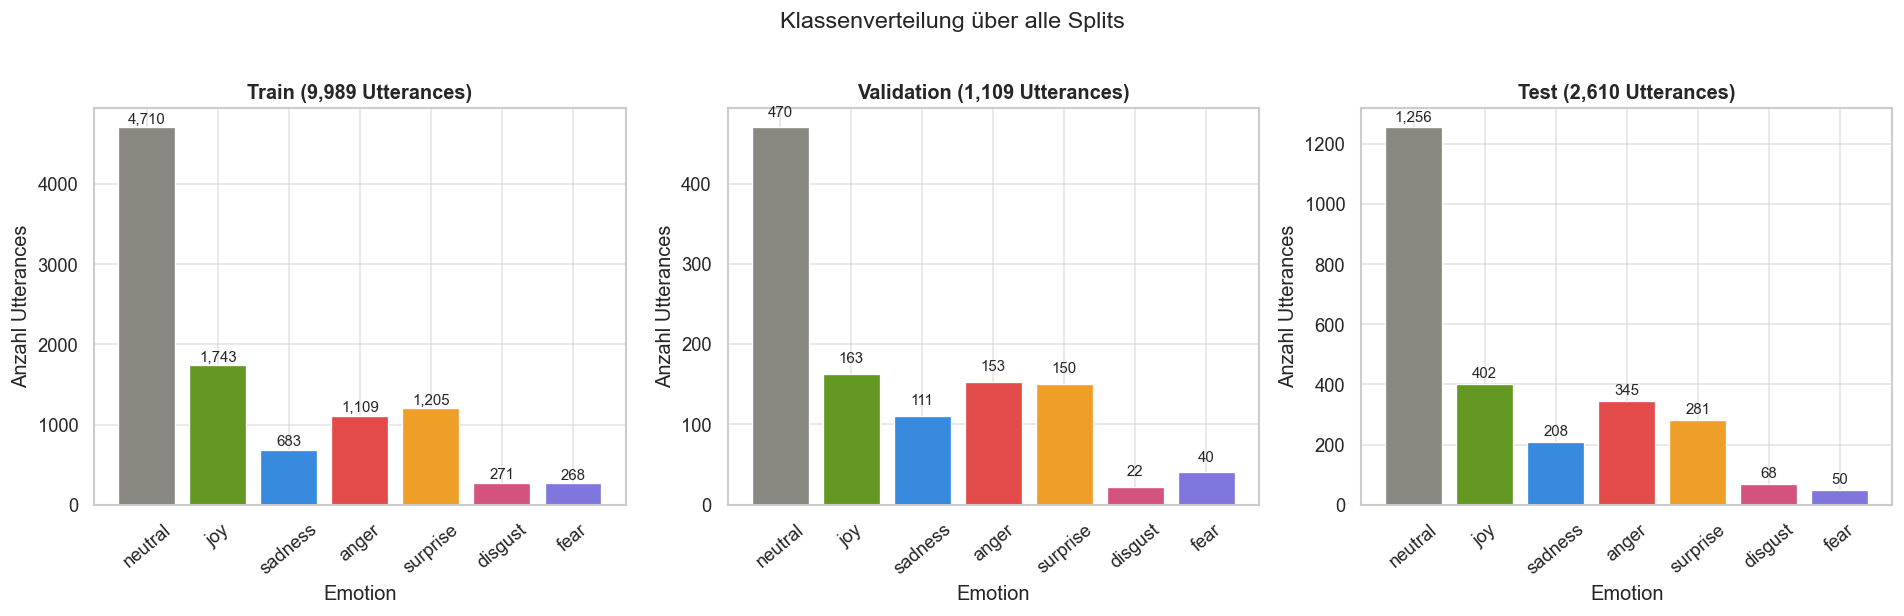

Plot gespeichert.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (df, title) in zip(axes, [
    (train_df, "Train"), (val_df, "Validation"), (test_df, "Test")
]):
    counts = df["emotion"].value_counts().reindex(EMOTION_ORDER).fillna(0)
    colors = [EMOTION_COLORS[e] for e in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{title} ({len(df):,} Utterances)", fontweight="bold")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Anzahl Utterances")
    ax.tick_params(axis="x", rotation=40)
    # Werte über den Balken
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 10, f"{int(h):,}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Klassenverteilung über alle Splits", fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/class_distribution.png", bbox_inches="tight")
plt.show()
print("Plot gespeichert.")

In [6]:
# Relative Verteilung in Prozent
print("Relative Klassenverteilung (in %):")
dist = (
    all_df.groupby(["split", "emotion"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=EMOTION_ORDER)
)
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100
display(dist_pct.round(1))

Relative Klassenverteilung (in %):


emotion,neutral,joy,sadness,anger,surprise,disgust,fear
split,,,,,,,
test,48.1,15.4,8.0,13.2,10.8,2.6,1.9
train,47.2,17.4,6.8,11.1,12.1,2.7,2.7
val,42.4,14.7,10.0,13.8,13.5,2.0,3.6


**Beobachtung:** Neutral macht ~46% der Trainingsdaten aus. Fear und Disgust sind sehr selten (<2%). Das macht Macro F1 besonders schwierig und erklärt den Fokus auf Weighted F1.

## 4. Textanalyse – Utterance-Längen

In [7]:
# Token-Länge (Wortbasiert als schnelle Schätzung)
all_df["n_words"] = all_df["utterance"].str.split().str.len()
all_df["n_chars"]  = all_df["utterance"].str.len()

print("Utterance-Länge (Wörter) – Gesamtdatensatz:")
print(all_df["n_words"].describe().round(1))
print(all_df.groupby("emotion")["n_words"].agg(["mean", "median"]).round(1))

Utterance-Länge (Wörter) – Gesamtdatensatz:
count    13708.0
mean         8.0
std          6.2
min          1.0
25%          3.0
50%          6.0
75%         11.0
max         69.0
Name: n_words, dtype: float64
          mean  median
emotion               
anger      9.2     8.0
disgust   10.0     8.0
fear       9.3     8.0
joy        7.7     6.0
neutral    7.8     6.0
sadness    9.9     8.5
surprise   6.0     5.0


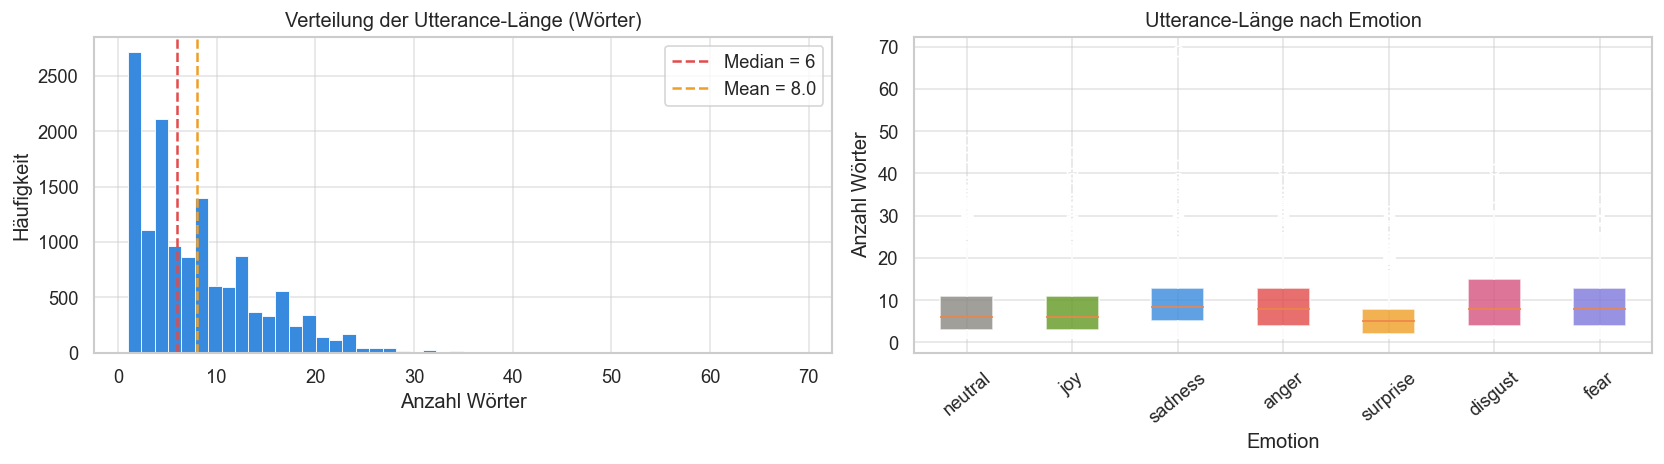

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram Wortanzahl
axes[0].hist(all_df["n_words"], bins=50, color="#378ADD", edgecolor="white", linewidth=0.5)
axes[0].axvline(all_df["n_words"].median(), color="#E24B4A", linestyle="--", label=f"Median = {all_df['n_words'].median():.0f}")
axes[0].axvline(all_df["n_words"].mean(), color="#EF9F27", linestyle="--", label=f"Mean = {all_df['n_words'].mean():.1f}")
axes[0].set_xlabel("Anzahl Wörter")
axes[0].set_ylabel("Häufigkeit")
axes[0].set_title("Verteilung der Utterance-Länge (Wörter)")
axes[0].legend()

# Boxplot pro Emotion
emotion_data = [all_df[all_df["emotion"] == e]["n_words"].values for e in EMOTION_ORDER]
bp = axes[1].boxplot(emotion_data, tick_labels=EMOTION_ORDER, patch_artist=True, notch=False)
for patch, e in zip(bp["boxes"], EMOTION_ORDER):
    patch.set_facecolor(EMOTION_COLORS[e])
    patch.set_alpha(0.8)
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Anzahl Wörter")
axes[1].set_title("Utterance-Länge nach Emotion")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("../outputs/plots/utterance_lengths.png", bbox_inches="tight")
plt.show()

In [9]:
# 512-Token-Grenze bei BERT/RoBERTa: Wie viele Utterances sind zu lang?
# (grobe Schätzung: 1 Wort ≈ 1.3 Tokens)
all_df["est_tokens"] = (all_df["n_words"] * 1.3).round().astype(int)
too_long = (all_df["est_tokens"] > 512).sum()
print(f"Utterances mit schätzungsweise >512 Tokens: {too_long} ({too_long/len(all_df)*100:.1f}%)")
print("→ Kein Truncation-Problem zu erwarten.")

Utterances mit schätzungsweise >512 Tokens: 0 (0.0%)
→ Kein Truncation-Problem zu erwarten.


## 5. Sprecher-Analyse

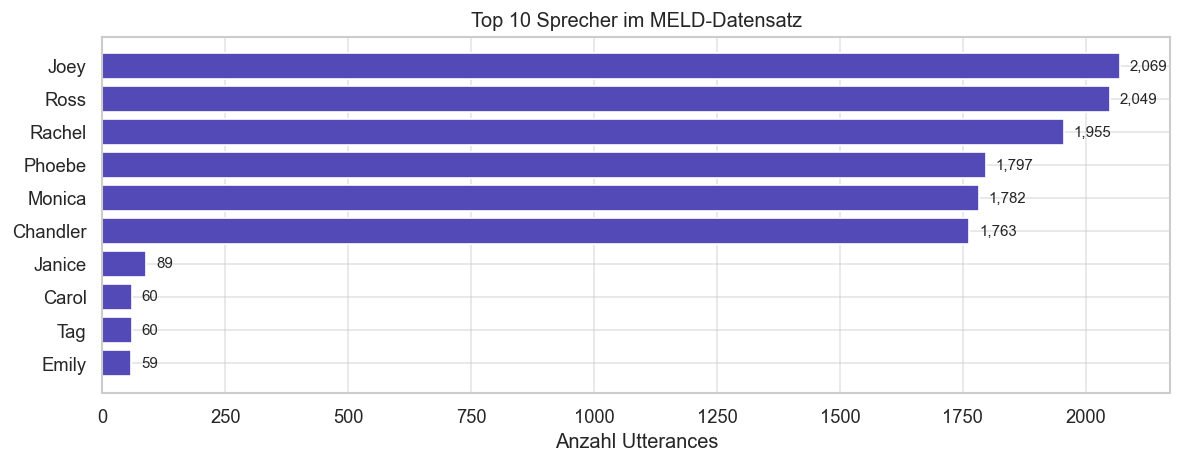

In [10]:
top_speakers = all_df["speaker"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top_speakers.index[::-1], top_speakers.values[::-1], color="#534AB7")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2, f"{int(w):,}", va="center", fontsize=9)
ax.set_xlabel("Anzahl Utterances")
ax.set_title("Top 10 Sprecher im MELD-Datensatz")
plt.tight_layout()
plt.savefig("../outputs/plots/speaker_distribution.png", bbox_inches="tight")
plt.show()

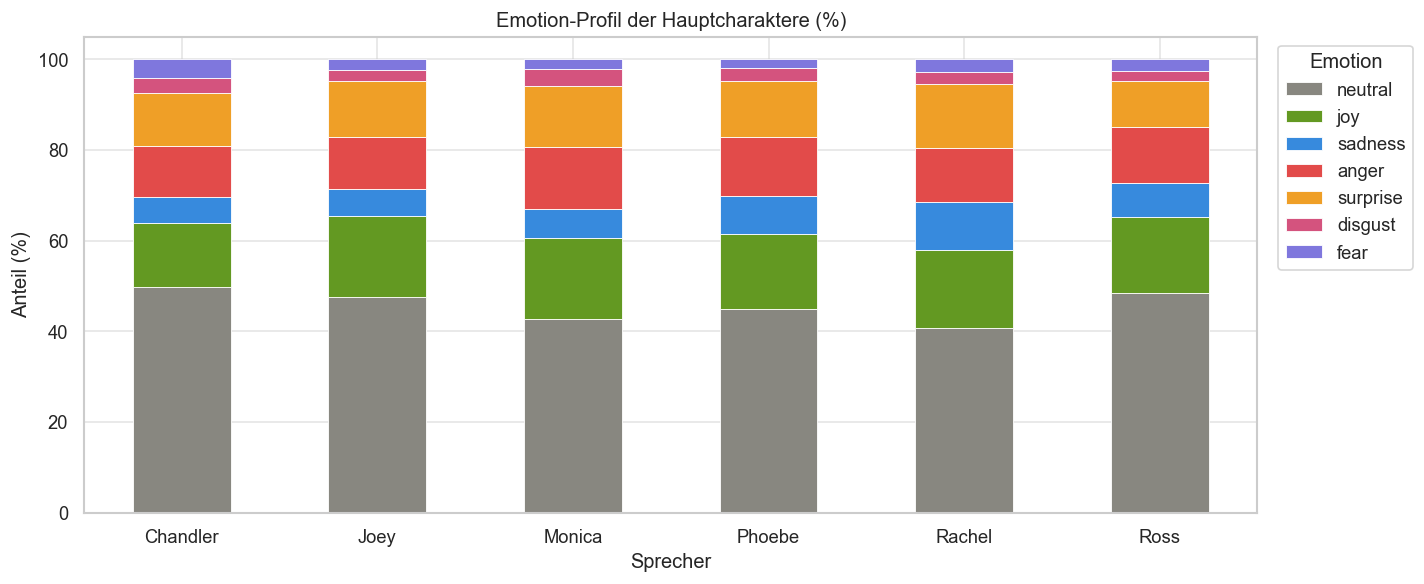

In [11]:
# Emotion-Profil der Hauptsprecher
main_chars = ["Ross", "Rachel", "Monica", "Chandler", "Joey", "Phoebe"]
speaker_emotion = (
    all_df[all_df["speaker"].isin(main_chars)]
    .groupby(["speaker", "emotion"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=EMOTION_ORDER)
)
speaker_emotion_pct = speaker_emotion.div(speaker_emotion.sum(axis=1), axis=0) * 100

speaker_emotion_pct.plot(
    kind="bar", stacked=True,
    color=[EMOTION_COLORS[e] for e in EMOTION_ORDER],
    figsize=(12, 5), edgecolor="white", linewidth=0.5
)
plt.title("Emotion-Profil der Hauptcharaktere (%)")
plt.xlabel("Sprecher")
plt.ylabel("Anteil (%)")
plt.xticks(rotation=0)
plt.legend(title="Emotion", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/plots/speaker_emotion_profile.png", bbox_inches="tight")
plt.show()

## 6. Dialog-Analyse

Utterances pro Dialog:
count    1432.0
mean        9.6
std         5.8
min         1.0
25%         5.0
50%         9.0
75%        14.0
max        33.0
Name: utterance_id, dtype: float64


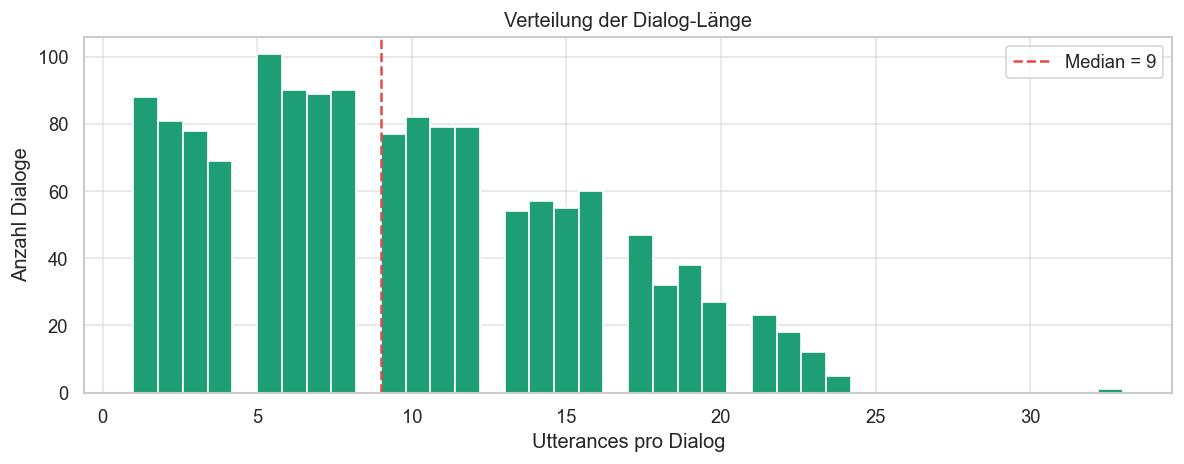

In [12]:
dialog_lengths = all_df.groupby(["split", "dialogue_id"])["utterance_id"].count()

print("Utterances pro Dialog:")
print(dialog_lengths.describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dialog_lengths.values, bins=40, color="#1D9E75", edgecolor="white")
ax.axvline(dialog_lengths.median(), color="#E24B4A", linestyle="--",
           label=f"Median = {dialog_lengths.median():.0f}")
ax.set_xlabel("Utterances pro Dialog")
ax.set_ylabel("Anzahl Dialoge")
ax.set_title("Verteilung der Dialog-Länge")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/dialog_lengths.png", bbox_inches="tight")
plt.show()

## 7. Emotion-Übergänge im Dialog

Wir schauen, welche Emotionen häufig aufeinanderfolgen. Das gibt Hinweise, ob Gesprächskontext für die Klassifikation nützlich wäre.

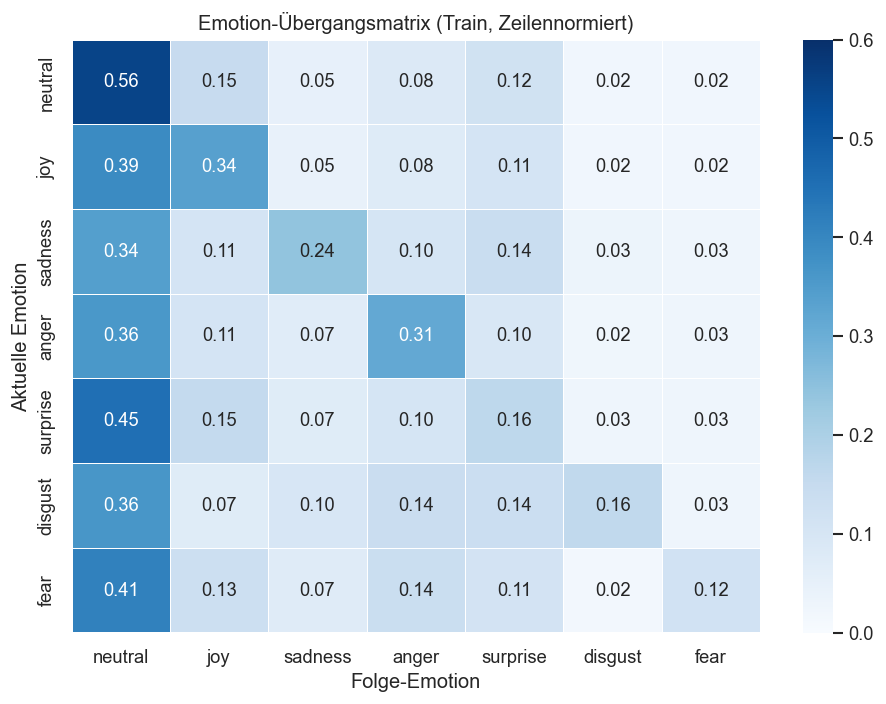

In [13]:
def compute_transition_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Berechnet die Übergangsmatrix zwischen aufeinanderfolgenden Emotionen."""
    transitions = []
    for _, group in df.groupby("dialogue_id"):
        group = group.sort_values("utterance_id")
        emotions = group["emotion"].tolist()
        for i in range(len(emotions) - 1):
            transitions.append((emotions[i], emotions[i + 1]))
    
    trans_df = pd.DataFrame(transitions, columns=["from", "to"])
    matrix = pd.crosstab(trans_df["from"], trans_df["to"])
    # Normalisieren: Zeilensumme = 1 (Übergangswahrscheinlichkeit)
    matrix = matrix.reindex(index=EMOTION_ORDER, columns=EMOTION_ORDER, fill_value=0)
    return matrix.div(matrix.sum(axis=1), axis=0)

trans_matrix = compute_transition_matrix(train_df)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    trans_matrix, annot=True, fmt=".2f",
    cmap="Blues", linewidths=0.5, ax=ax,
    vmin=0, vmax=0.6
)
ax.set_title("Emotion-Übergangsmatrix (Train, Zeilennormiert)")
ax.set_xlabel("Folge-Emotion")
ax.set_ylabel("Aktuelle Emotion")
plt.tight_layout()
plt.savefig("../outputs/plots/emotion_transitions.png", bbox_inches="tight")
plt.show()

## 8. Häufige Wörter pro Emotion

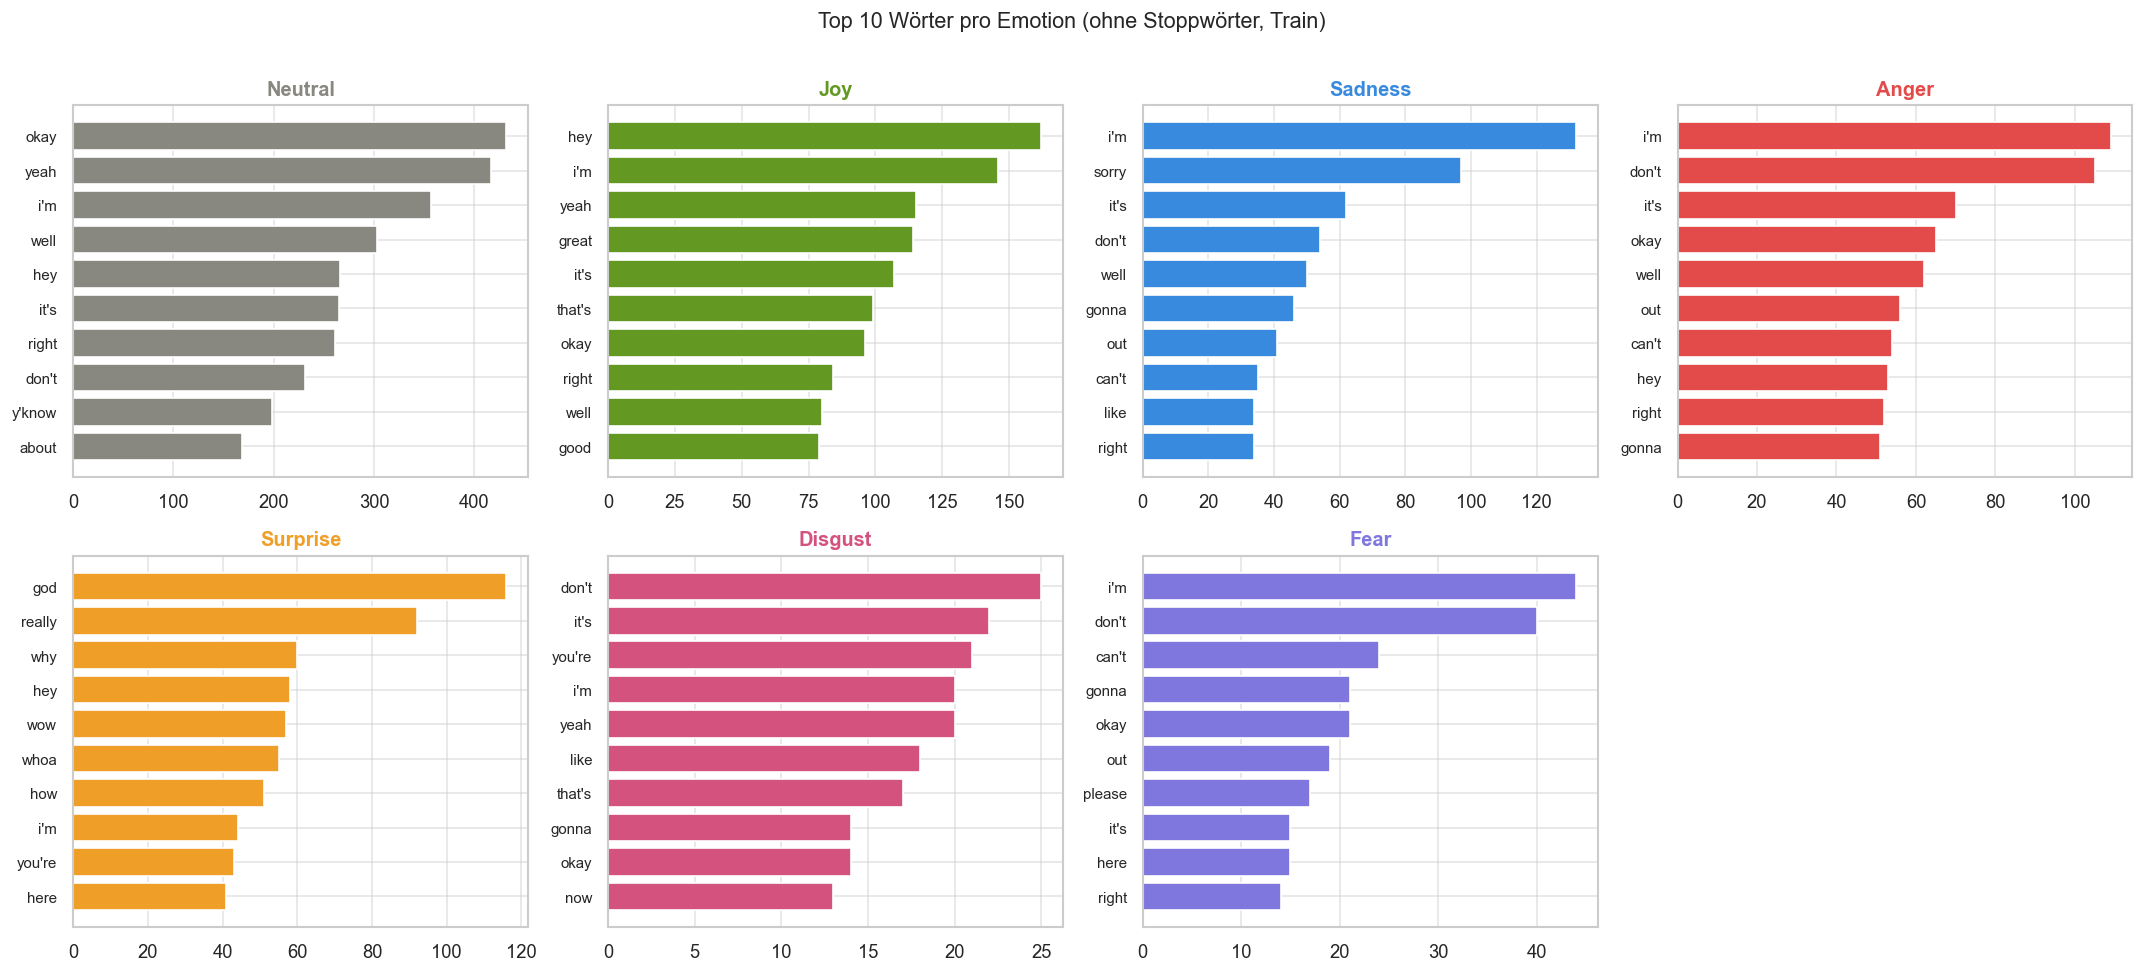

In [14]:
import re

STOPWORDS = {
    "i", "you", "the", "a", "to", "it", "is", "and", "of", "that",
    "in", "my", "me", "we", "do", "this", "he", "she", "be", "for",
    "was", "not", "have", "on", "are", "with", "your", "just", "so",
    "what", "but", "oh", "at", "all", "no", "can", "know", "up",
    "will", "or", "did", "going", "get", "dont", "its", "he", "her"
}

def top_words(texts, n=10):
    words = re.findall(r"[a-z']+", " ".join(texts).lower())
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, emotion in enumerate(EMOTION_ORDER):
    texts = train_df[train_df["emotion"] == emotion]["utterance"].tolist()
    words, counts = zip(*top_words(texts, 10)) if texts else ([], [])
    color = EMOTION_COLORS[emotion]
    axes[i].barh(list(words)[::-1], list(counts)[::-1], color=color)
    axes[i].set_title(emotion.capitalize(), fontweight="bold", color=color)
    axes[i].tick_params(axis="y", labelsize=9)

axes[-1].set_visible(False)
fig.suptitle("Top 10 Wörter pro Emotion (ohne Stoppwörter, Train)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plots/top_words_per_emotion.png", bbox_inches="tight")
plt.show()

## 9. Sentiment vs. Emotion

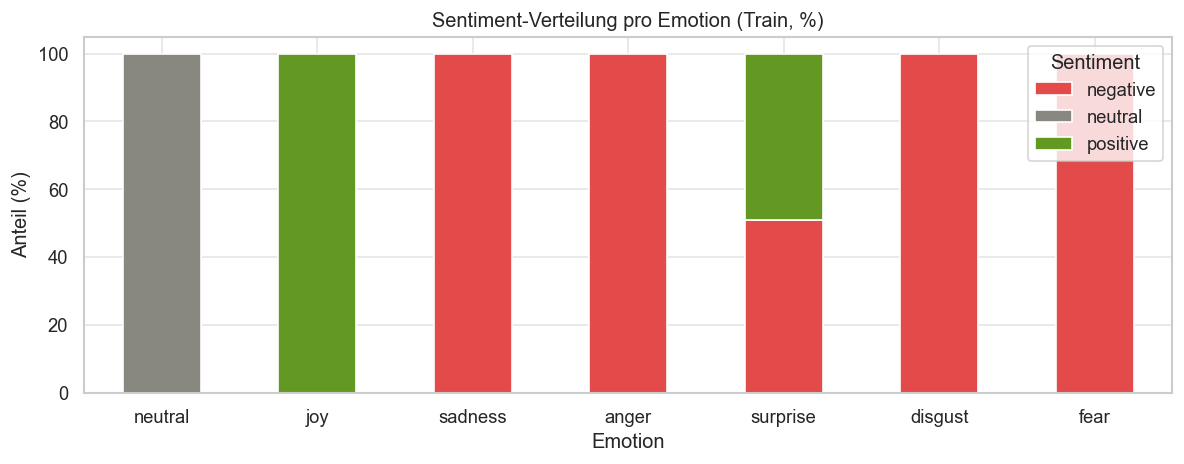

In [15]:
# MELD enthält auch ein Sentiment-Label (positive / negative / neutral)
# Nützlich als Sanity-Check: Joy → positiv, Anger/Sadness → negativ, etc.
sent_emo = pd.crosstab(train_df["emotion"], train_df["sentiment"])
sent_emo = sent_emo.reindex(EMOTION_ORDER)

sent_emo_pct = sent_emo.div(sent_emo.sum(axis=1), axis=0) * 100

sent_emo_pct.plot(
    kind="bar", stacked=True,
    color=["#E24B4A", "#888780", "#639922"],
    figsize=(10, 4), edgecolor="white"
)
plt.title("Sentiment-Verteilung pro Emotion (Train, %)")
plt.xlabel("Emotion")
plt.ylabel("Anteil (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig("../outputs/plots/sentiment_vs_emotion.png", bbox_inches="tight")
plt.show()

## 10. Audio-Exploration (optional – falls .wav-Dateien vorhanden)

Struktur der MELD-Audio-Dateien: `dia{dialogue_id}_utt{utterance_id}.wav`

In [16]:
import subprocess
import soundfile as sf
import io

def load_audio_from_mp4(path, sr=16_000):
    """Extrahiert Audio aus .mp4 via ffmpeg und lädt es als numpy array."""
    cmd = [
        "ffmpeg", "-i", str(path),
        "-f", "wav",
        "-ar", str(sr),
        "-ac", "1",
        "-loglevel", "quiet",
        "pipe:1"
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    audio, file_sr = sf.read(io.BytesIO(result.stdout))
    return audio, file_sr

if not LIBROSA_AVAILABLE:
    print("librosa nicht verfügbar – Audio-Zellen übersprungen.")
elif not AUDIO_ROOT.exists():
    print(f"Audio-Ordner {AUDIO_ROOT} nicht gefunden – Download MELD-Audio zuerst.")
else:
    def build_audio_path(row):
        return AUDIO_ROOT / f"dia{row['dialogue_id']}_utt{row['utterance_id']}.mp4"

    train_df["audio_path"] = train_df.apply(build_audio_path, axis=1)
    train_df["audio_exists"] = train_df["audio_path"].apply(lambda p: p.exists())

    print(f"{train_df['audio_exists'].sum():,} Audio-Dateien gefunden.")

    fig, axes = plt.subplots(len(EMOTION_ORDER), 2, figsize=(14, 3 * len(EMOTION_ORDER)))

    for i, emotion in enumerate(EMOTION_ORDER):
        subset = train_df[(train_df["emotion"] == emotion) & train_df["audio_exists"]]
        if subset.empty:
            axes[i, 0].set_title(f"{emotion} – kein Audio"); continue

        row = subset.iloc[0]
        y, sr = load_audio_from_mp4(row["audio_path"], sr=16_000)  # <-- angepasst
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], color=EMOTION_COLORS[emotion])
        axes[i, 0].set_title(f"{emotion.capitalize()} – Waveform")
        axes[i, 0].set_xlabel("Zeit (s)")

        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel",
                                  ax=axes[i, 1], cmap="magma")
        axes[i, 1].set_title(f"{emotion.capitalize()} – Mel-Spektrogramm")
        axes[i, 1].set_xlabel("Zeit (s)")

    plt.suptitle("Audio-Beispiele pro Emotion", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("../outputs/plots/audio_examples.png", bbox_inches="tight")
    plt.show()

librosa nicht verfügbar – Audio-Zellen übersprungen.


## 11. Data-Leakage-Check

Wir prüfen, ob Dialoge oder Utterances über Splits hinweg dupliziert sind.

In [17]:
# Utterance-Level Leakage Check
# Schlüssel: dialogue_id + utterance_id + season + episode

train_utt_keys = set(
    zip(train_df["dialogue_id"], train_df["utterance_id"],
        train_df["season"],      train_df["episode"])
)
test_utt_keys = set(
    zip(test_df["dialogue_id"], test_df["utterance_id"],
        test_df["season"],      test_df["episode"])
)

overlap_utterances = train_utt_keys & test_utt_keys
print(f"Überschneidungen auf Utterance-Ebene: {len(overlap_utterances)}")

# Falls es Überschneidungen gibt – Details anzeigen
if overlap_utterances:
    # Als DataFrame aufbereiten
    overlap_utt_df = pd.DataFrame(
        list(overlap_utterances),
        columns=["dialogue_id", "utterance_id", "season", "episode"]
    )

    # Train-Seite
    train_side = train_df.merge(
        overlap_utt_df,
        on=["dialogue_id", "utterance_id", "season", "episode"]
    )[["dialogue_id", "utterance_id", "season", "episode", "utterance", "emotion"]]

    # Test-Seite
    test_side = test_df.merge(
        overlap_utt_df,
        on=["dialogue_id", "utterance_id", "season", "episode"]
    )[["dialogue_id", "utterance_id", "season", "episode", "utterance", "emotion"]]

    # Zusammenführen zum direkten Vergleich
    comparison = train_side.merge(
        test_side,
        on=["dialogue_id", "utterance_id", "season", "episode"],
        suffixes=("_train", "_test")
    )

    print("\nDirektvergleich Train vs. Test:")
    print(comparison[["dialogue_id", "utterance_id", "season", "episode",
                        "utterance_train", "emotion_train",
                        "utterance_test",  "emotion_test"]])

    # Haben dieselben Utterances auch dieselben Labels?
    label_conflict = comparison[
        comparison["emotion_train"] != comparison["emotion_test"]
    ]
    print(f"\nLabel-Konflikte (gleiche Utterance, verschiedene Emotion): "
          f"{len(label_conflict)}")

Überschneidungen auf Utterance-Ebene: 21

Direktvergleich Train vs. Test:
    dialogue_id  utterance_id  season  episode  \
0            19             0       1        1   
1           103             0       8        4   
2           103             1       8        4   
3           103             2       8        4   
4           103             3       8        4   
5           103             4       8        4   
6           103             5       8        4   
7           104             0       8       23   
8           104             1       8       23   
9           182             0       5       10   
10          182             1       5       10   
11          182             2       5       10   
12          182             3       5       10   
13          182             4       5       10   
14          182             5       5       10   
15          182             6       5       10   
16          182             7       5       10   
17          182           

In [18]:
# Zur Sicherheit: Text-Identität prüfen
comparison["text_identical"] = (
comparison["utterance_train"].str.strip().str.lower() ==
comparison["utterance_test"].str.strip().str.lower()
)

print("Text-identische Utterances:")
print(comparison["text_identical"].value_counts())

print("\nNur echte Text-Duplikate:")
print(comparison[comparison["text_identical"]][
["dialogue_id", "utterance_id", "season", "episode",
 "utterance_train", "emotion_train", "emotion_test"]
])

Text-identische Utterances:
text_identical
False    21
Name: count, dtype: int64

Nur echte Text-Duplikate:
Empty DataFrame
Columns: [dialogue_id, utterance_id, season, episode, utterance_train, emotion_train, emotion_test]
Index: []


## 12. Majority-Class-Baseline

Die einfachste Baseline: immer die häufigste Klasse vorhersagen. Dies ist unser unterer Grenzwert.

In [19]:
from sklearn.metrics import f1_score, accuracy_score

majority_class = train_df["emotion"].mode()[0]
print(f"Majority Class (Train): '{majority_class}'")

for split_name, df in [("Val", val_df), ("Test", test_df)]:
    y_true = df["emotion"]
    y_pred = [majority_class] * len(df)
    wf1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    mf1    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    acc    = accuracy_score(y_true, y_pred)
    print(f"\nMajority Baseline ({split_name}):")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Weighted F1 : {wf1:.4f}")
    print(f"  Macro F1    : {mf1:.4f}")

Majority Class (Train): 'neutral'

Majority Baseline (Val):
  Accuracy    : 0.4238
  Weighted F1 : 0.2523
  Macro F1    : 0.0850

Majority Baseline (Test):
  Accuracy    : 0.4812
  Weighted F1 : 0.3127
  Macro F1    : 0.0928


## 13. Zusammenfassung & Key Insights

In [20]:
print("="*60)
print("  MELD Dataset – Key Insights")
print("="*60)

print(f"""
Datensatzgrösse:
  Train : {len(train_df):>6,} Utterances  |  {train_df['dialogue_id'].nunique():>4} Dialoge
  Val   : {len(val_df):>6,} Utterances  |  {val_df['dialogue_id'].nunique():>4} Dialoge
  Test  : {len(test_df):>6,} Utterances  |  {test_df['dialogue_id'].nunique():>4} Dialoge

Klassenverteilung (Train, Top 3 / Bottom 3):
  Grösste Klasse  : {train_df['emotion'].value_counts().index[0]} \
({train_df['emotion'].value_counts().iloc[0]/len(train_df)*100:.1f}%)
  Kleinste Klasse : {train_df['emotion'].value_counts().index[-1]} \
({train_df['emotion'].value_counts().iloc[-1]/len(train_df)*100:.1f}%)
  Imbalance-Ratio : {train_df['emotion'].value_counts().iloc[0] / train_df['emotion'].value_counts().iloc[-1]:.1f}x

Utterance-Länge (Wörter):
  Median : {all_df['n_words'].median():.0f}  |  Mean : {all_df['n_words'].mean():.1f}  |  Max : {all_df['n_words'].max()}

Konsequenzen für das Modell:
  • Weighted F1 als Hauptmetrik (wegen Klassenimbalance)
  • Macro F1 ergänzend berichten (seltene Klassen wie Fear, Disgust)
  • Keine Truncation-Probleme bei BERT/RoBERTa erwartet
  • Kein Data Leakage zwischen offiziellen Splits
  • Majority Baseline ≈ {majority_class} → weighted F1 bereits ohne Modell schätzbar
""")

  MELD Dataset – Key Insights

Datensatzgrösse:
  Train :  9,989 Utterances  |  1038 Dialoge
  Val   :  1,109 Utterances  |   114 Dialoge
  Test  :  2,610 Utterances  |   280 Dialoge

Klassenverteilung (Train, Top 3 / Bottom 3):
  Grösste Klasse  : neutral (47.2%)
  Kleinste Klasse : fear (2.7%)
  Imbalance-Ratio : 17.6x

Utterance-Länge (Wörter):
  Median : 6  |  Mean : 8.0  |  Max : 69

Konsequenzen für das Modell:
  • Weighted F1 als Hauptmetrik (wegen Klassenimbalance)
  • Macro F1 ergänzend berichten (seltene Klassen wie Fear, Disgust)
  • Keine Truncation-Probleme bei BERT/RoBERTa erwartet
  • Kein Data Leakage zwischen offiziellen Splits
  • Majority Baseline ≈ neutral → weighted F1 bereits ohne Modell schätzbar



## Nächste Schritte

Nach der Exploration empfehlen wir folgende Reihenfolge:

1. **`src/config.py`** – Pfade, Hyperparameter, Label-Mapping definieren
2. **`src/data_loading.py`** – `MELDDataset` als PyTorch Dataset implementieren
3. **`src/text_model.py`** – RoBERTa / DistilRoBERTa Klassifikator
4. **`src/audio_model.py`** – Wav2Vec2 / HuBERT Feature-Extractor + Classifier
5. **`src/fusion_model.py`** – Softmax-Fusion (avg, weighted, meta-classifier)
6. **`src/evaluation.py`** – Einheitliche Evaluations-Pipeline
7. **`main.py`** – Experiment-Runner